In [ ]:
# Exercise 1 | Convert dictionary to list of tuples for sorting (revisiting exercise 4 from 09_dictionaries)
def count_emails_per_sender(file_name):
    file_to_open = 'files/' + file_name
    emails_per_sender = {}
    with open(file_to_open) as file:
        for line in file:
            words = line.split()
            if (len(words) < 3 or words[0] != 'From'):
                continue
            sender = words[1]
            emails_per_sender[sender] = emails_per_sender.get(sender,0) + 1
    return emails_per_sender

emails_per_sender = count_emails_per_sender('mbox-short.txt')
list_to_sort = [(v, k) for k, v in emails_per_sender.items()]
sorted_counts = sorted(list_to_sort, reverse=True)
print(sorted_counts[0][1],sorted_counts[0][0])

cwen@iupui.edu 5


In [ ]:
# Exercise 2 | Convert dictionary to list of tuples for sorting
def count_emails_per_hour_of_the_day(file_name):
    file_to_open = 'files/' + file_name
    emails_per_hour = {}
    with open(file_to_open) as file:
        for line in file:
            words = line.split()
            if (len(words) < 6 or words[0] != 'From'):
                continue
            timestamp = words[5]
            hour = (timestamp.split(":"))[0]
            emails_per_hour[hour] = emails_per_hour.get(hour,0) + 1
    return emails_per_hour

emails_per_hour = count_emails_per_hour_of_the_day('mbox-short.txt')
sorted_counts = sorted(emails_per_hour.items())
for hour,count in sorted_counts:
    print(hour,count)

In [ ]:
# Exercise 3 | Frequency analysis of letters in text
import re
import string
import matplotlib.pyplot as plt
import numpy as np

def parse_file_to_text(file_name):
    file_path = 'files/' + file_name
    with open(file_path) as file:
        content = file.read()
    return content

def strip_non_alphabetical_from_text(text):
    cleaned_text = re.sub(r'[^a-zA-Z]', '', text)
    return cleaned_text.lower()

def count_letter_occucrences(text, sort_by_alphabet=False):
    letter_counts = dict.fromkeys(string.ascii_lowercase, 0)
    for letter in text:
        letter_counts[letter] += 1

    if sort_by_alphabet:
        return sorted(letter_counts.items())
    
    swapped = [(v, k) for k, v in letter_counts.items()]
    sorted_swapped = sorted(swapped, reverse=True)
    return [(k, v) for v, k in sorted_swapped]

def analyze_letter_frequency_in_file(file_name, sort_by_alphabet=False):
    file_content = parse_file_to_text(file_name)
    cleaned_text = strip_non_alphabetical_from_text(file_content)
    return count_letter_occucrences(cleaned_text,sort_by_alphabet)

file_name = 'alice_wonderland/italian.txt'
letter_counts = analyze_letter_frequency_in_file(file_name)
print(letter_counts)

[('e', 13054), ('a', 12468), ('i', 10717), ('o', 10108), ('n', 7522), ('r', 6974), ('l', 6766), ('s', 6520), ('t', 6296), ('c', 5804), ('d', 3704), ('u', 3491), ('p', 3222), ('m', 2738), ('v', 2326), ('g', 2123), ('h', 1468), ('f', 1128), ('b', 1097), ('z', 731), ('q', 645), ('j', 33), ('x', 8), ('k', 1), ('y', 0), ('w', 0)]


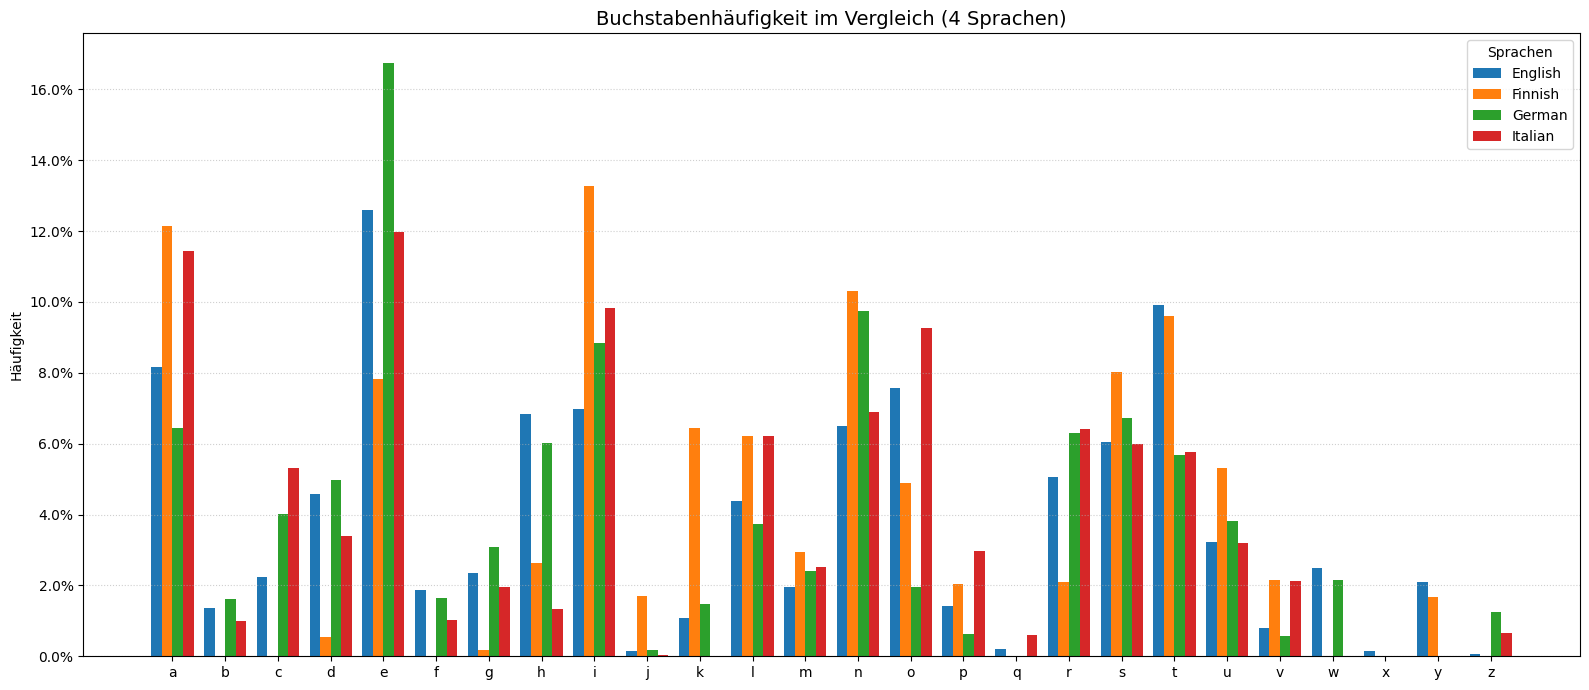

In [66]:
# Compare letter frequency in different languages (additional task) 
import matplotlib.ticker as mtick
def plot_language_comparison(frequency_dict):
    # 1. Basis-Daten extrahieren
    languages = list(frequency_dict.keys())
    num_langs = len(languages)
    
    # Alphabet aus dem ersten Eintrag ziehen
    first_lang_data = frequency_dict[languages[0]]
    alphabet = [tup[0] for tup in first_lang_data]
    
    x = np.arange(len(alphabet))  # Positionen 0-25
    
    # 2. Dynamische Breite berechnen
    # Ein Gruppen-Block (für einen Buchstaben) hat die Breite 0.8 (von 1.0)
    # Diese 0.8 teilen wir durch die Anzahl der Sprachen
    total_group_width = 0.8
    width = total_group_width / num_langs 
    
    fig, ax = plt.subplots(figsize=(16, 7))

    # 3. Balken plotten
    for i, lang in enumerate(languages):
        values = [tup[1] for tup in frequency_dict[lang]]
        
        # Berechnung des Offsets, damit die Gruppe zentriert über dem Buchstaben steht
        # Formel: (Aktueller Index - Mitte der Indizes) * Breite
        offset = (i - (num_langs - 1) / 2) * width
        ax.bar(x + offset, values, width, label=lang.capitalize())

    # 4. Styling
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(f'Buchstabenhäufigkeit im Vergleich ({num_langs} Sprachen)', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(alphabet)
    ax.set_ylabel('Häufigkeit')
    ax.legend(title="Sprachen")
    
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

#languages = ['english', 'esperanto', 'finnish', 'french', 'german', 'italian']
languages = ['english', 'finnish', 'german', 'italian']
letter_frequencies_per_language = {}
for language in languages:
    file_name = 'alice_wonderland/' + language + '.txt'
    raw_data = analyze_letter_frequency_in_file(file_name, True)
    total = sum(count for char, count in raw_data)
    letter_frequencies_per_language[language] = [(char, count / total) for char, count in raw_data]
plot_language_comparison(letter_frequencies_per_language)